In [ ]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
bc = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/bitcoin_price.csv')
bc.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [ ]:
ap = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/airline_passengers.csv')
ap.head(5)

,Month,Thousands of Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
# Question No. 1

bc['expanded_mean'] = bc['Close'].expanding(min_periods=30).mean()
final_expanded_mean = bc['expanded_mean'].iloc[-1]
final_expanded_mean

14574.914414459805

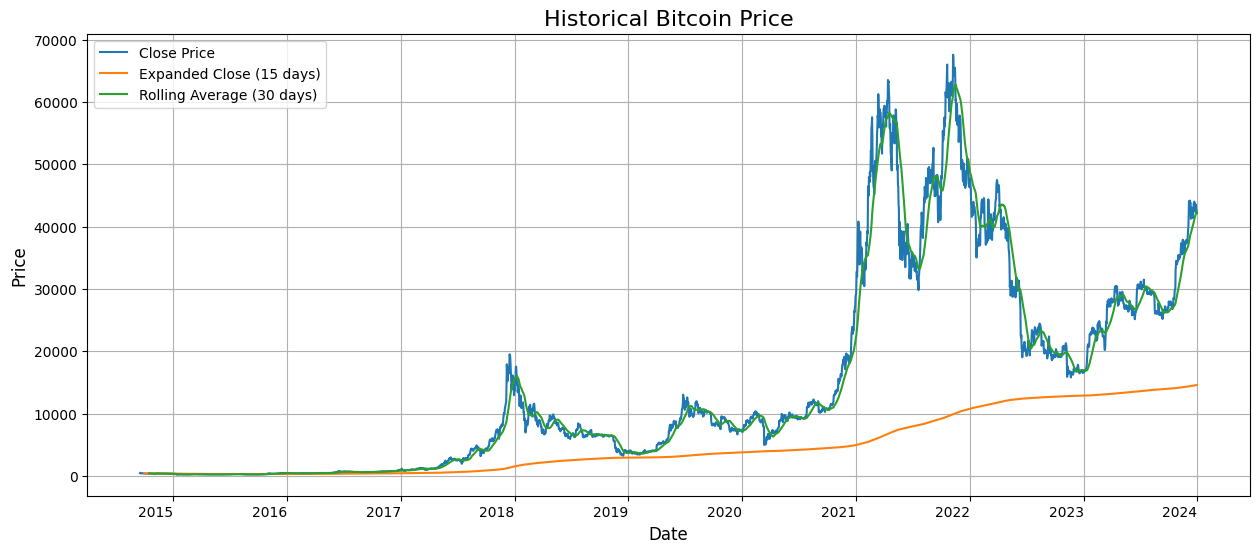

In [ ]:
# Question No. 2

bc['expanded_close_15'] = bc['Close'].expanding(min_periods=15).mean()
bc['expanded_close_30'] = bc['Close'].expanding(min_periods=30).mean()
bc['rolling_close_30'] = bc['Close'].rolling(window=30).mean()
bc = bc.set_index('Date')
bc.index = pd.to_datetime(bc.index)

plt.style.use('default')
plt.figure(figsize=(15, 6))

plt.plot(bc.index, bc['Close'], label='Close Price')
plt.plot(bc.index, bc['expanded_close_15'], label='Expanded Close (15 days)')
plt.plot(bc.index, bc['rolling_close_30'], label='Rolling Average (30 days)')

plt.title("Historical Bitcoin Price", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True)
plt.legend(loc='upper left')
plt.xticks(rotation=0, ha='right')
plt.show()

# **Question No. 3**

Bitcoin prices are highly volatile, showing rapid surges followed by sharp declines. Despite short-term crashes, the long-term trend remains upward. Bitcoin prices go up and down a lot, but over time, they keep growing. Big price jumps are followed by drops, creating cycles. Important events, like Bitcoin halving and more people investing, often cause big price spikes.

In [ ]:
# Question No. 4

filtered_bc = bc[(bc.index >= '2021-01-01') & (bc.index <= '2023-12-31')]
highest_price = filtered_bc['Close'].max()
lowest_price = filtered_bc['Close'].min()

In [ ]:
highest_price

67566.828125

In [ ]:
lowest_price

15787.2841796875

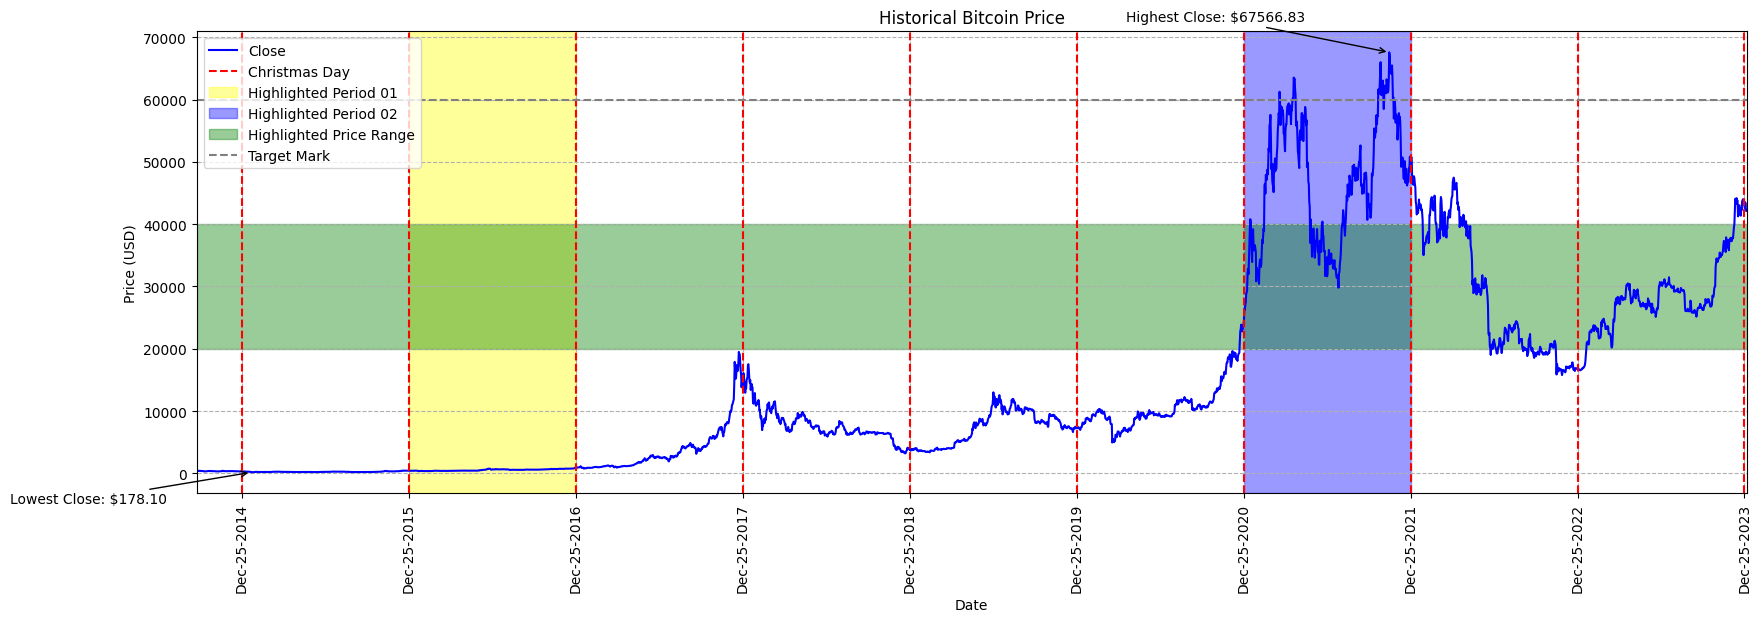

In [ ]:
# Quesion No. 5

import matplotlib.dates as mdates

url = "https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/bitcoin_price.csv"
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')

fig, ax = plt.subplots(figsize=(20, 6))

ax.plot(df.index, df['Close'], label="Close", color="blue")
ax.set_xlim(df.index.min(), df.index.max())

for year in range(df.index.year.min(), df.index.year.max() + 1):
    ax.axvline(pd.Timestamp(f"{year}-12-25"), color="red", linestyle="dashed", label="Christmas Day" if year == df.index.year.min() else "")

ax.axvspan(pd.Timestamp('2015-12-25'), pd.Timestamp('2016-12-25'), color='yellow', alpha=0.4, label="Highlighted Period 01")
ax.axvspan(pd.Timestamp('2020-12-25'), pd.Timestamp('2021-12-25'), color='blue', alpha=0.4, label="Highlighted Period 02")

ax.axhspan(20000, 40000, color='green', alpha=0.4, label="Highlighted Price Range")

ax.axhline(y=60000, color='gray', linestyle="dashed", label="Target Mark")

# Annotate lowest price (Modified)
min_close = df['Close'].min()
min_date = df['Close'].idxmin()
ax.annotate(f"Lowest Close: ${min_close:.2f}", xy=(min_date, min_close), xytext=(min_date - pd.DateOffset(months=6), min_close - 5000), # Adjusted xytext
            arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=10, ha='right')  # Added ha='right'

# Annotate highest price (Added)
max_close = df['Close'].max()
max_date = df['Close'].idxmax()
ax.annotate(f"Highest Close: ${max_close:.2f}", xy=(max_date, max_close), xytext=(max_date - pd.DateOffset(months=6), max_close + 5000),  # Adjusted xytext
            arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=10, ha='right')  # Added ha='rig

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

christmas_dates = [pd.Timestamp(f"{year}-12-25") for year in range(df.index.year.min(), df.index.year.max() + 1)]
plt.xticks(christmas_dates, [d.strftime('%b-%d-%Y') for d in christmas_dates], rotation=90)

plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.title("Historical Bitcoin Price")
plt.legend(loc='upper left')
plt.grid(linestyle='--')

plt.show()

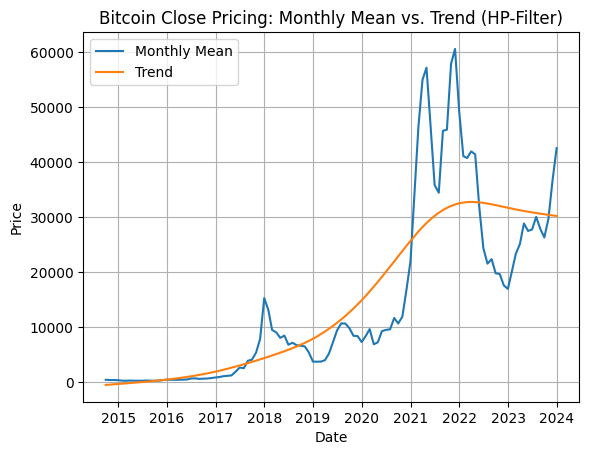

In [ ]:
# Question No. 6

import statsmodels.api as sm
bc_monthly = bc['Close'].resample('ME').mean()
cycle, trend = sm.tsa.filters.hpfilter(bc_monthly, lamb=14400)

plt.plot(bc_monthly, label='Monthly Mean')
plt.plot(trend, label='Trend')
plt.title('Bitcoin Close Pricing: Monthly Mean vs. Trend (HP-Filter)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.show()

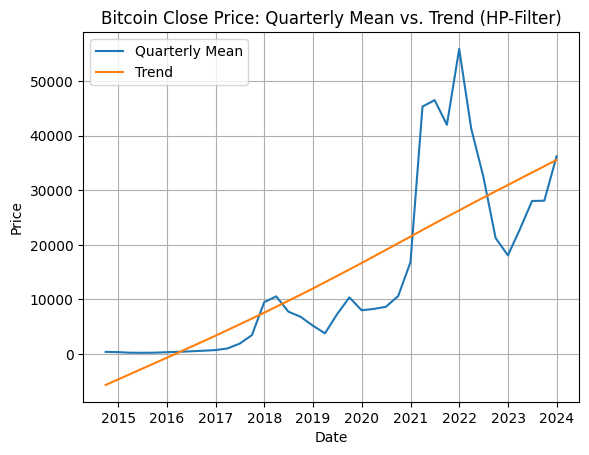

In [ ]:
# Question No. 7

import statsmodels.api as sm
bc_quarterly = bc['Close'].resample('QE').mean()
cycle, trend = sm.tsa.filters.hpfilter(bc_quarterly, lamb=14400)

plt.plot(bc_quarterly, label='Quarterly Mean')
plt.plot(trend, label='Trend')
plt.title('Bitcoin Close Price: Quarterly Mean vs. Trend (HP-Filter)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.show()

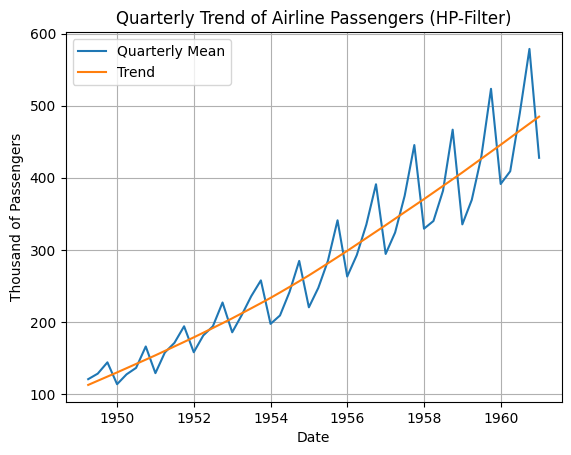

In [ ]:
# Question No. 8

import statsmodels.api as sm

ap = ap.set_index(pd.to_datetime(ap['Month'], format='%Y-%m'))
ap_quarterly = ap['Thousands of Passengers'].resample('QE').mean()
cycle, trend = sm.tsa.filters.hpfilter(ap_quarterly, lamb=1600)

plt.plot(ap_quarterly, label='Quarterly Mean')
plt.plot(trend, label='Trend')
plt.title('Quarterly Trend of Airline Passengers (HP-Filter)')
plt.xlabel('Date')
plt.ylabel('Thousand of Passengers')
plt.grid(True)
plt.legend()
plt.show()

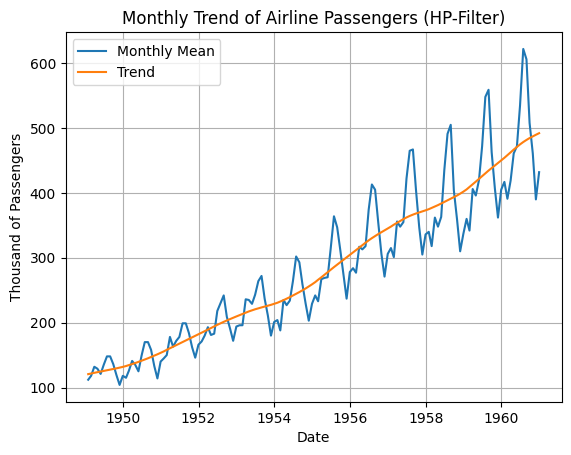

In [ ]:
# Question No. 9

import statsmodels.api as sm

ap = ap.set_index(pd.to_datetime(ap['Month'], format='%Y-%m'))
ap_monthly = ap['Thousands of Passengers'].resample('ME').mean()
cycle, trend = sm.tsa.filters.hpfilter(ap_monthly, lamb=1600)

plt.plot(ap_monthly, label='Monthly Mean')
plt.plot(trend, label='Trend')
plt.title('Monthly Trend of Airline Passengers (HP-Filter)')
plt.xlabel('Date')
plt.ylabel('Thousand of Passengers')
plt.grid(True)
plt.legend()
plt.show()

<ipython-input-486-70e6347378c9>:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bc_monthly = bc['Close'].resample('M').mean()
<ipython-input-486-70e6347378c9>:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ap_monthly = ap['Thousands of Passengers'].resample('M').mean()


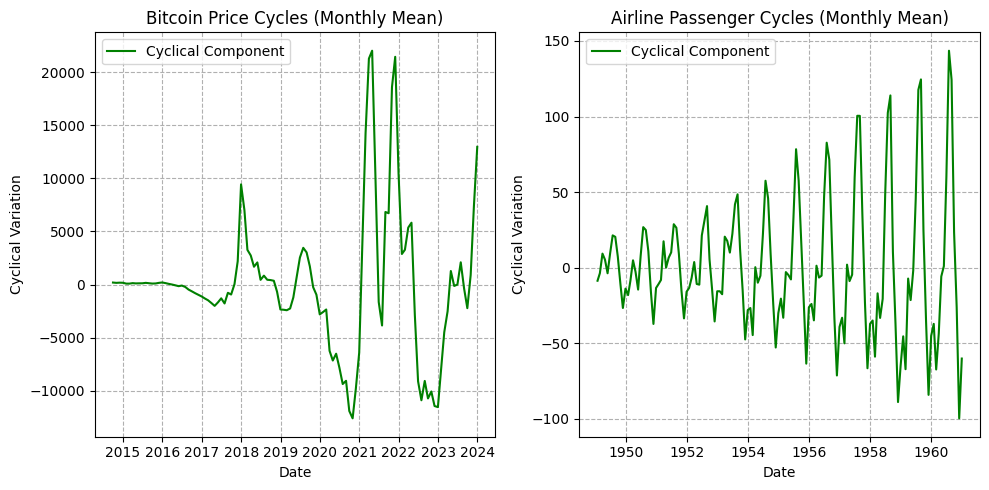

In [ ]:
# Question No. 10

from statsmodels.tsa.filters.hp_filter import hpfilter

# Bitcoin

url = "https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/bitcoin_price.csv"
bc = pd.read_csv(url, parse_dates=['Date'], index_col='Date')

bc_monthly = bc['Close'].resample('M').mean()

cycle_btc, trend_btc = hpfilter(bc_monthly, lamb=1600)

# Airline

ap = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/airline_passengers.csv')
ap['Month'] = pd.to_datetime(ap['Month'])
ap.set_index('Month', inplace=True)

ap_monthly = ap['Thousands of Passengers'].resample('M').mean()

cycle_ap, trend_ap = hpfilter(ap_monthly, lamb=1600)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))  # 2 rows, 1 column

# Plot For Bitcoin
ax1.plot(cycle_btc, label='Cyclical Component', color='green')
ax1.set_title('Bitcoin Price Cycles (Monthly Mean)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cyclical Variation')
ax1.legend(loc='upper left')
ax1.grid(linestyle='--')

# Plot For Airline
ax2.plot(cycle_ap, label='Cyclical Component', color='green')
ax2.set_title('Airline Passenger Cycles (Monthly Mean)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cyclical Variation')
ax2.legend(loc='upper left')
ax2.grid(linestyle='--')

plt.tight_layout()

plt.show()